# Network Intrusion Detection — LightGBM + SMOTEENN
**Course:** Advanced Python (ICS0019)  
**Approach:** LightGBM with SMOTEENN resampling  
**Metric:** Macro F1-score on KDDTest+  

This notebook implements a complete pipeline:
1. Data loading & preprocessing (starter code)
2. Feature engineering (new features to help detect R2L/U2R)
3. SMOTEENN resampling (oversample minorities + clean noisy boundaries)
4. LightGBM training with class weights
5. Hyperparameter tuning with RandomizedSearchCV
6. Cross-validation vs test score comparison
7. Final evaluation with classification report + confusion matrix


## 0. Setup — Install Libraries & Configure GPU


In [1]:
# ============================================================
# STEP 0: Install required libraries and configure environment
# ============================================================
# Run this cell first! It installs libraries not pre-installed in Colab.
# LightGBM supports GPU acceleration out of the box in Colab.

!pip install lightgbm imbalanced-learn --quiet

# Verify GPU is available (optional — model works on CPU too, just slower)
import subprocess
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout[:500])
    GPU_AVAILABLE = True
    print("\n✅ GPU detected! LightGBM will use GPU acceleration.")
except FileNotFoundError:
    GPU_AVAILABLE = False
    print("⚠️ No GPU detected. Model will train on CPU (still fast for this dataset).")


Fri May 22 18:53:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       

✅ GPU detected! LightGBM will use GPU acceleration.


## 1. Load the NSL-KDD Dataset


In [2]:
# ============================================================
# STEP 1: Load the NSL-KDD dataset from GitHub
# ============================================================
# This is the starter code provided by the teacher.
# KDDTrain+ = 125,973 records for training
# KDDTest+  = 22,544 records for evaluation
# The test set contains attack types NOT in the training data (realistic!)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility (required by assignment)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# URLs for the dataset
train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
test_url  = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

# Column names (41 features + class label + difficulty level)
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'class', 'level'
]

print("Loading data...")
df_train = pd.read_csv(train_url, names=columns)
df_test  = pd.read_csv(test_url, names=columns)

# Drop the difficulty level column (not a feature, just metadata)
df_train.drop(columns=['level'], inplace=True)
df_test.drop(columns=['level'], inplace=True)

print(f"Training set: {df_train.shape[0]:,} records, {df_train.shape[1]} columns")
print(f"Test set:     {df_test.shape[0]:,} records, {df_test.shape[1]} columns")


Loading data...
Training set: 125,973 records, 42 columns
Test set:     22,544 records, 42 columns


## 2. Encode Categorical Features


In [3]:
# ============================================================
# STEP 2: Convert text categories to numbers
# ============================================================
# ML algorithms need numbers, not text. LabelEncoder converts
# e.g. "TCP" -> 0, "UDP" -> 1, "ICMP" -> 2
#
# We merge train+test temporarily so both get the SAME encoding
# (e.g. "TCP" is always 0 in both sets)

df_full = pd.concat([df_train, df_test])

cat_cols = ['protocol_type', 'service', 'flag']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_full[col] = le.fit_transform(df_full[col])
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values encoded")


  protocol_type: 3 unique values encoded
  service: 70 unique values encoded
  flag: 11 unique values encoded


## 3. Map Attack Types to 5 Categories


In [4]:
# ============================================================
# STEP 3: Map 39 specific attack names -> 5 categories
# ============================================================
# Normal = legitimate traffic
# DoS    = denial of service (flood attacks)
# Probe  = scanning/reconnaissance
# R2L    = remote-to-local (unauthorized remote access) -- RARE
# U2R    = user-to-root (privilege escalation) -- VERY RARE

category_map = {
    'normal': 'Normal',
    # DoS attacks
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS',
    'processtable': 'DoS', 'udpstorm': 'DoS', 'worm': 'DoS',
    # Probe attacks
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe',
    'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    # R2L attacks
    'warezclient': 'R2L', 'guess_passwd': 'R2L', 'ftp_write': 'R2L',
    'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L',
    'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L',
    'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    # U2R attacks
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R',
    'perl': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

df_full['category'] = df_full['class'].map(category_map).fillna('Other')

# Drop constant column and original class labels
df_full.drop(columns=['num_outbound_cmds', 'class'], inplace=True)

# Split back into train and test
train_len = len(df_train)
df_train_processed = df_full.iloc[:train_len].copy()
df_test_processed  = df_full.iloc[train_len:].copy()

X_train = df_train_processed.drop(columns=['category'])
y_train = df_train_processed['category']
X_test  = df_test_processed.drop(columns=['category'])
y_test  = df_test_processed['category']

print(f"Features: {X_train.shape[1]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts().to_string())
print(f"\nTest set class distribution:")
print(y_test.value_counts().to_string())


Features: 40

Training set class distribution:
category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52

Test set class distribution:
category
Normal    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67


## 4. Feature Engineering
Creating new features that may help the model distinguish R2L and U2R attacks from normal traffic. These are ratios and combinations of existing features that capture patterns the raw features might miss.


In [5]:
# ============================================================
# STEP 4: Create new features from existing ones
# ============================================================
# WHY: R2L and U2R attacks often have subtle patterns in traffic
# ratios that raw features don't capture directly.

def add_features(df):
    """Add engineered features to a dataframe."""
    # Ratio of bytes sent vs received (attacks often have unusual ratios)
    df['bytes_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)

    # Total error rate (combines two error indicators)
    df['error_rate_sum'] = df['serror_rate'] + df['rerror_rate']

    # Host service ratio (how concentrated is traffic to one service)
    df['host_srv_ratio'] = df['dst_host_srv_count'] / (df['dst_host_count'] + 1)

    # Total bytes transferred
    df['total_bytes'] = df['src_bytes'] + df['dst_bytes']

    # Host error rates combined
    df['host_error_sum'] = df['dst_host_serror_rate'] + df['dst_host_rerror_rate']

    # Connection rate features
    df['srv_diff_ratio'] = df['srv_diff_host_rate'] / (df['same_srv_rate'] + 1)

    return df

X_train = add_features(X_train)
X_test  = add_features(X_test)

print(f"Features after engineering: {X_train.shape[1]} (was 40, added 6 new)")
print(f"New features: bytes_ratio, error_rate_sum, host_srv_ratio, total_bytes, host_error_sum, srv_diff_ratio")


Features after engineering: 46 (was 40, added 6 new)
New features: bytes_ratio, error_rate_sum, host_srv_ratio, total_bytes, host_error_sum, srv_diff_ratio


## 5. Apply SMOTEENN Resampling
**SMOTEENN** = SMOTE + Edited Nearest Neighbors. It does two things:
1. **SMOTE** creates synthetic samples for minority classes (R2L, U2R) by interpolating between existing samples
2. **ENN** then removes samples that are misclassified by their nearest neighbors (cleans noisy boundaries)

This is more sophisticated than plain SMOTE and helps the model learn cleaner decision boundaries.


In [6]:
# ============================================================
# STEP 5: Resample training data with SMOTEENN
# ============================================================
from imblearn.combine import SMOTEENN

print("Before SMOTEENN:")
print(y_train.value_counts().to_string())
print(f"Total: {len(y_train):,}")

# Apply SMOTEENN — this may take 30-60 seconds
print("\nApplying SMOTEENN (this takes ~30-60 seconds)...")
smoteenn = SMOTEENN(random_state=RANDOM_STATE)
X_train_res, y_train_res = smoteenn.fit_resample(X_train, y_train)

print(f"\nAfter SMOTEENN:")
print(pd.Series(y_train_res).value_counts().to_string())
print(f"Total: {len(y_train_res):,}")
print(f"\nSMOTEENN increased minority classes and cleaned noisy samples.")


Before SMOTEENN:
category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Total: 125,973

Applying SMOTEENN (this takes ~30-60 seconds)...

After SMOTEENN:
category
DoS       67116
U2R       67109
R2L       67012
Probe     67010
Normal    66334
Total: 334,581

SMOTEENN increased minority classes and cleaned noisy samples.


## 6. Experiment 1 — Baseline LightGBM (no resampling)
First, let's see how LightGBM does WITHOUT any resampling, just to have our own baseline.


In [7]:
# ============================================================
# EXPERIMENT 1: LightGBM with default settings, NO resampling
# ============================================================
import lightgbm as lgb
from sklearn.metrics import classification_report, f1_score

# Determine device type
device_type = 'gpu' if GPU_AVAILABLE else 'cpu'
print(f"Using device: {device_type}")

model_baseline = lgb.LGBMClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    verbose=-1,
    device=device_type,    # Use GPU if available
    n_jobs=-1
)

model_baseline.fit(X_train, y_train)
y_pred_baseline = model_baseline.predict(X_test)

f1_baseline = f1_score(y_test, y_pred_baseline, average='macro')
print(f"\n=== Experiment 1: Baseline LightGBM (no resampling) ===")
print(f"Macro F1-score: {f1_baseline:.4f}")
print(f"\n{classification_report(y_test, y_pred_baseline, digits=4)}")


Using device: gpu

=== Experiment 1: Baseline LightGBM (no resampling) ===
Macro F1-score: 0.4516

              precision    recall  f1-score   support

         DoS     0.9114    0.7625    0.8303      7460
      Normal     0.6400    0.9753    0.7729      9711
       Probe     0.8572    0.5109    0.6403      2421
         R2L     0.5000    0.0073    0.0143      2885
         U2R     0.0000    0.0000    0.0000        67

    accuracy                         0.7282     22544
   macro avg     0.5817    0.4512    0.4516     22544
weighted avg     0.7333    0.7282    0.6783     22544



## 7. Experiment 2 — LightGBM + SMOTEENN


In [8]:
# ============================================================
# EXPERIMENT 2: LightGBM trained on SMOTEENN-resampled data
# ============================================================
model_smoteenn = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1,
    device='cpu',       # <-- changed from device_type
    n_jobs=-1
)

model_smoteenn.fit(X_train_res, y_train_res)
y_pred_smoteenn = model_smoteenn.predict(X_test)

f1_smoteenn = f1_score(y_test, y_pred_smoteenn, average='macro')
print(f"=== Experiment 2: LightGBM + SMOTEENN ===")
print(f"Macro F1-score: {f1_smoteenn:.4f} (baseline was {f1_baseline:.4f})")
print(f"Improvement: +{f1_smoteenn - f1_baseline:.4f}")
print(f"\n{classification_report(y_test, y_pred_smoteenn, digits=4)}")


=== Experiment 2: LightGBM + SMOTEENN ===
Macro F1-score: 0.6390 (baseline was 0.4516)
Improvement: +0.1874

              precision    recall  f1-score   support

         DoS     0.9630    0.8198    0.8857      7460
      Normal     0.7037    0.9708    0.8159      9711
       Probe     0.8413    0.7968    0.8184      2421
         R2L     0.9874    0.1626    0.2792      2885
         U2R     0.6552    0.2836    0.3958        67

    accuracy                         0.7967     22544
   macro avg     0.8301    0.6067    0.6390     22544
weighted avg     0.8404    0.7967    0.7693     22544



## 8. Experiment 3 — LightGBM + SMOTEENN + class_weight only (no SMOTEENN)
Let's also try just class_weight='balanced' without SMOTEENN for comparison.


In [9]:
# ============================================================
# EXPERIMENT 3: LightGBM with class_weight='balanced' only (no SMOTEENN)
# ============================================================
model_cw = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1,
    device='cpu',
    n_jobs=-1
)

# Train on ORIGINAL data (not resampled), relying only on class_weight
model_cw.fit(X_train, y_train)
y_pred_cw = model_cw.predict(X_test)

f1_cw = f1_score(y_test, y_pred_cw, average='macro')
print(f"=== Experiment 3: LightGBM + class_weight='balanced' (no SMOTEENN) ===")
print(f"Macro F1-score: {f1_cw:.4f}")
print(f"\n{classification_report(y_test, y_pred_cw, digits=4)}")


=== Experiment 3: LightGBM + class_weight='balanced' (no SMOTEENN) ===
Macro F1-score: 0.5816

              precision    recall  f1-score   support

         DoS     0.9637    0.8300    0.8919      7460
      Normal     0.6773    0.9713    0.7981      9711
       Probe     0.8619    0.7092    0.7782      2421
         R2L     0.9615    0.0607    0.1141      2885
         U2R     0.7368    0.2090    0.3256        67

    accuracy                         0.7776     22544
   macro avg     0.8403    0.5560    0.5816     22544
weighted avg     0.8285    0.7776    0.7380     22544



## 9. Experiment 4 — Hyperparameter Tuning with RandomizedSearchCV
Now let's find the best hyperparameters using RandomizedSearchCV. This tries random combinations and picks the best one based on cross-validation.


In [11]:
# ============================================================
# EXPERIMENT 4: Hyperparameter tuning
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Define the search space — these are the ranges LightGBM will explore
param_dist = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(4, 12),
    'learning_rate': uniform(0.01, 0.15),
    'num_leaves': randint(31, 127),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_samples': randint(5, 50),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

# Base model for tuning (trained on SMOTEENN data)
lgbm_tuner = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    verbose=-1,
    device=device_type,
    n_jobs=-1
)

# RandomizedSearchCV: try 30 random parameter combinations, 3-fold CV
# Using 3 folds instead of 5 to save time during tuning
print("Running RandomizedSearchCV (this may take 5-15 minutes)...")
print("Trying 30 random parameter combinations with 3-fold CV...\n")

search = RandomizedSearchCV(
    lgbm_tuner,
    param_distributions=param_dist,
    n_iter=30,              # Try 30 random combinations
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_res, y_train_res)

print(f"\nBest CV Macro F1: {search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in search.best_params_.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


Running RandomizedSearchCV (this may take 5-15 minutes)...
Trying 30 random parameter combinations with 3-fold CV...

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best CV Macro F1: 0.9999
Best parameters:
  colsample_bytree: 0.6323
  learning_rate: 0.0654
  max_depth: 4
  min_child_samples: 42
  n_estimators: 479
  num_leaves: 99
  reg_alpha: 0.6323
  reg_lambda: 0.6335
  subsample: 0.8143


## 10. Evaluate the Tuned Model


In [12]:
# ============================================================
# STEP 10: Evaluate tuned model on KDDTest+
# ============================================================
best_model = search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')
print(f"=== Experiment 4: Tuned LightGBM + SMOTEENN ===")
print(f"Macro F1-score: {f1_tuned:.4f}")
print(f"\n{classification_report(y_test, y_pred_tuned, digits=4)}")


=== Experiment 4: Tuned LightGBM + SMOTEENN ===
Macro F1-score: 0.6727

              precision    recall  f1-score   support

         DoS     0.9624    0.8074    0.8781      7460
      Normal     0.7051    0.9705    0.8168      9711
       Probe     0.8349    0.7955    0.8147      2421
         R2L     0.9895    0.1955    0.3265      2885
         U2R     0.6744    0.4328    0.5273        67

    accuracy                         0.7970     22544
   macro avg     0.8333    0.6404    0.6727     22544
weighted avg     0.8405    0.7970    0.7733     22544



## 11. Pick the Best Model & Final Evaluation
Compare all experiments and use the best one for the final report.


In [13]:
# ============================================================
# STEP 11: Compare all experiments
# ============================================================
results = {
    "1. Baseline LightGBM": f1_baseline,
    "2. LightGBM + SMOTEENN": f1_smoteenn,
    "3. LightGBM + class_weight only": f1_cw,
    "4. Tuned LightGBM + SMOTEENN": f1_tuned,
}

print("=" * 55)
print("EXPERIMENTS SUMMARY")
print("=" * 55)
for name, score in results.items():
    print(f"  {name:40s} {score:.4f}")
print("=" * 55)

# Pick the best
best_name = max(results, key=results.get)
best_f1 = results[best_name]
print(f"\nBest: {best_name} with Macro F1 = {best_f1:.4f}")

# Use the best model's predictions for confusion matrix
if best_name == "4. Tuned LightGBM + SMOTEENN":
    y_pred_final = y_pred_tuned
    final_model = best_model
elif best_name == "2. LightGBM + SMOTEENN":
    y_pred_final = y_pred_smoteenn
    final_model = model_smoteenn
elif best_name == "3. LightGBM + class_weight only":
    y_pred_final = y_pred_cw
    final_model = model_cw
else:
    y_pred_final = y_pred_baseline
    final_model = model_baseline

print(f"\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final, digits=4))


EXPERIMENTS SUMMARY
  1. Baseline LightGBM                     0.4516
  2. LightGBM + SMOTEENN                   0.6390
  3. LightGBM + class_weight only          0.5816
  4. Tuned LightGBM + SMOTEENN             0.6727

Best: 4. Tuned LightGBM + SMOTEENN with Macro F1 = 0.6727

Final Classification Report:
              precision    recall  f1-score   support

         DoS     0.9624    0.8074    0.8781      7460
      Normal     0.7051    0.9705    0.8168      9711
       Probe     0.8349    0.7955    0.8147      2421
         R2L     0.9895    0.1955    0.3265      2885
         U2R     0.6744    0.4328    0.5273        67

    accuracy                         0.7970     22544
   macro avg     0.8333    0.6404    0.6727     22544
weighted avg     0.8405    0.7970    0.7733     22544



## 12. Cross-Validation vs Test Score (MANDATORY)


In [14]:
# ============================================================
# STEP 12: Cross-validation on training set (MANDATORY for report)
# ============================================================
# The teacher requires you to compare CV score with test score.
# We run 5-fold CV using imblearn Pipeline so SMOTEENN is applied
# inside each fold (no data leakage).

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score

print("Running 5-fold cross-validation with SMOTEENN pipeline...")
print("(This takes a few minutes — SMOTEENN runs 5 times)\n")

# Create a pipeline that does SMOTEENN + LightGBM inside each fold
cv_pipeline = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=RANDOM_STATE)),
    ('clf', lgb.LGBMClassifier(
        **search.best_params_,  # Use the best hyperparameters we found
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1,
        device=device_type,
        n_jobs=-1
    ))
])

cv_scores = cross_val_score(
    cv_pipeline,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=1  # n_jobs=1 because SMOTEENN is memory-heavy
)

print(f"Cross-validation Macro F1: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"Individual fold scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"\nTest set Macro F1:       {best_f1:.4f}")
print(f"Gap (CV - Test):         {cv_scores.mean() - best_f1:+.4f}")

if cv_scores.mean() > best_f1:
    print("\n→ CV score > Test score: This is EXPECTED because KDDTest+ contains")
    print("  attack types not seen during training. A moderate gap is normal.")
elif cv_scores.mean() < best_f1 - 0.05:
    print("\n→ CV score << Test score: Unusual. May indicate the model generalizes")
    print("  differently to the test distribution. Worth noting in the report.")
else:
    print("\n→ Scores are close: The model generalizes well.")


Running 5-fold cross-validation with SMOTEENN pipeline...
(This takes a few minutes — SMOTEENN runs 5 times)

Cross-validation Macro F1: 0.9394 (±0.0160)
Individual fold scores: ['0.9240', '0.9506', '0.9641', '0.9357', '0.9224']

Test set Macro F1:       0.6727
Gap (CV - Test):         +0.2667

→ CV score > Test score: This is EXPECTED because KDDTest+ contains
  attack types not seen during training. A moderate gap is normal.


## 13. Confusion Matrix (REQUIRED for report)


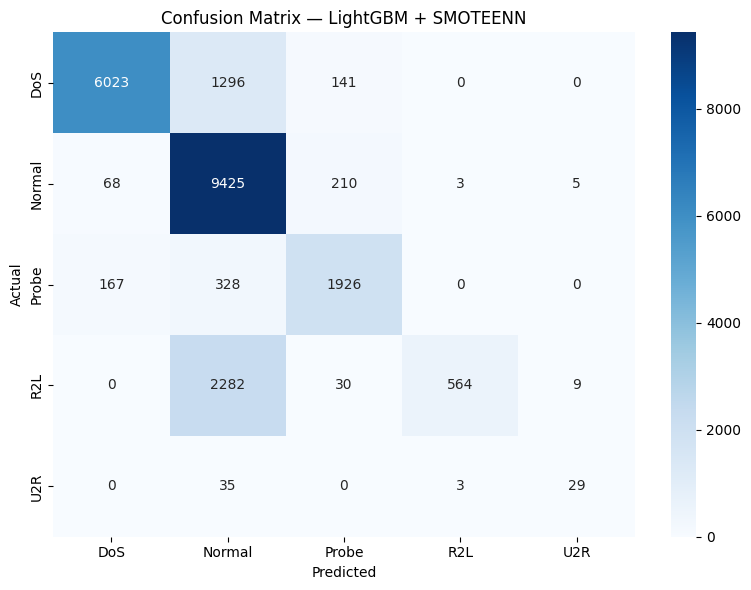


Confusion matrix saved as 'confusion_matrix.png'
Download it and include it in your report!


In [15]:
# ============================================================
# STEP 13: Generate and save confusion matrix
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["DoS", "Normal", "Probe", "R2L", "U2R"]
cm = confusion_matrix(y_test, y_pred_final, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — LightGBM + SMOTEENN")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nConfusion matrix saved as 'confusion_matrix.png'")
print("Download it and include it in your report!")


## 14. Feature Importance (useful for report)


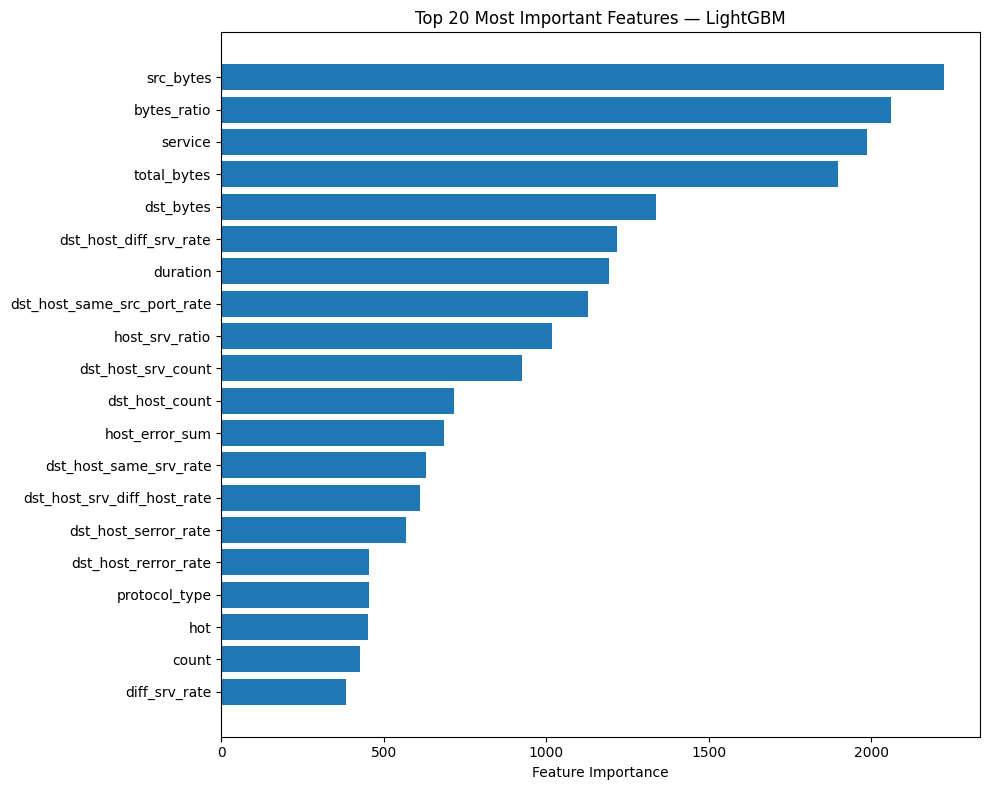

In [16]:
# ============================================================
# STEP 14: Which features matter most?
# ============================================================
# This is great material for the report — shows which network
# characteristics are most useful for detecting attacks.

import matplotlib.pyplot as plt

importance = final_model.feature_importances_
feature_names = X_train.columns
sorted_idx = np.argsort(importance)[-20:]  # Top 20

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Top 20 Most Important Features — LightGBM")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


## 15. Summary for Your Report
Run this cell to get a copy-paste-ready summary for your report.


In [17]:
# ============================================================
# STEP 15: Print report-ready summary
# ============================================================
print("=" * 60)
print("REPORT SUMMARY")
print("=" * 60)

print(f"""
1. APPROACH
   Algorithm: LightGBM (Gradient Boosting)
   Imbalance handling: SMOTEENN + class_weight='balanced'
   Feature engineering: 6 new features (ratios & combinations)
   Hyperparameter tuning: RandomizedSearchCV (30 iterations, 3-fold CV)

2. BEST MODEL PARAMETERS:""")
for k, v in search.best_params_.items():
    if isinstance(v, float):
        print(f"   {k}: {v:.4f}")
    else:
        print(f"   {k}: {v}")

print(f"""
3. RESULTS
   Macro F1 (test):  {best_f1:.4f}
   Macro F1 (CV):    {cv_scores.mean():.4f} (±{cv_scores.std():.4f})
   Gap (CV - test):  {cv_scores.mean() - best_f1:+.4f}

4. EXPERIMENTS SUMMARY""")
for name, score in results.items():
    print(f"   {name:40s} {score:.4f}")

print(f"""
5. ENVIRONMENT
   Python: 3.x (Google Colab)
   LightGBM: {lgb.__version__}
   scikit-learn: {__import__('sklearn').__version__}
   imbalanced-learn: {__import__('imblearn').__version__}
   Random seed: {RANDOM_STATE}
   Device: {device_type}
""")


REPORT SUMMARY

1. APPROACH
   Algorithm: LightGBM (Gradient Boosting)
   Imbalance handling: SMOTEENN + class_weight='balanced'
   Feature engineering: 6 new features (ratios & combinations)
   Hyperparameter tuning: RandomizedSearchCV (30 iterations, 3-fold CV)

2. BEST MODEL PARAMETERS:
   colsample_bytree: 0.6323
   learning_rate: 0.0654
   max_depth: 4
   min_child_samples: 42
   n_estimators: 479
   num_leaves: 99
   reg_alpha: 0.6323
   reg_lambda: 0.6335
   subsample: 0.8143

3. RESULTS
   Macro F1 (test):  0.6727
   Macro F1 (CV):    0.9394 (±0.0160)
   Gap (CV - test):  +0.2667

4. EXPERIMENTS SUMMARY
   1. Baseline LightGBM                     0.4516
   2. LightGBM + SMOTEENN                   0.6390
   3. LightGBM + class_weight only          0.5816
   4. Tuned LightGBM + SMOTEENN             0.6727

5. ENVIRONMENT
   Python: 3.x (Google Colab)
   LightGBM: 4.6.0
   scikit-learn: 1.6.1
   imbalanced-learn: 0.14.1
   Random seed: 42
   Device: gpu

